# STEP 1 — Imports

In [2]:
# ============================================================
# STEP 1 — IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# STEP 2 — Load the common datasets

In [3]:
# ============================================================
# STEP 2 — LOAD THE PROCESSED DATA
# ============================================================

train_df = pd.read_csv("../../data/processed/train.csv")
validation_df = pd.read_csv("../../data/processed/validation.csv")
test_df = pd.read_csv("../../data/processed/test.csv")

print("Train shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)

Train shape: (7319483, 21)
Validation shape: (1326842, 21)
Test shape: (823955, 21)


# STEP 3 — Separate features and target

In [4]:
# ============================================================
# STEP 3 — SEPARATE FEATURES AND TARGET
# ============================================================

# The target column we want to predict
target_column = "wildfire"

# Separate input features (X) from the target (y)
X_train = train_df.drop(columns=[target_column])
y_train = train_df[target_column]

X_validation = validation_df.drop(columns=[target_column])
y_validation = validation_df[target_column]

X_test = test_df.drop(columns=[target_column])
y_test = test_df[target_column]

# Check the resulting shapes
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (7319483, 20)
y_train: (7319483,)
X_validation: (1326842, 20)
y_validation: (1326842,)
X_test: (823955, 20)
y_test: (823955,)


# STEP 4 — Check class imbalance

In [5]:
# ============================================================
# STEP 4 — CHECK CLASS DISTRIBUTION
# ============================================================

print("Training class distribution:")
print(y_train.value_counts())

print("\nValidation class distribution:")
print(y_validation.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training class distribution:
wildfire
0    7045069
1     274414
Name: count, dtype: int64

Validation class distribution:
wildfire
0    1218614
1     108228
Name: count, dtype: int64

Test class distribution:
wildfire
0    705565
1    118390
Name: count, dtype: int64


# STEP 5 — Create the baseline Random Forest

In [6]:
# ============================================================
# STEP 5 — CREATE BASELINE RANDOM FOREST
# ============================================================

# Create a Random Forest classifier.


rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Baseline Random Forest created successfully.")

Baseline Random Forest created successfully.


# STEP 6 — Train the baseline Random Forest

In [7]:
# ============================================================
# STEP 6 — TRAIN BASELINE RANDOM FOREST
# ============================================================

# Train the Random Forest using ONLY the training data.
#
# X_train = input features
# y_train = actual wildfire labels
#
# IMPORTANT:
# The validation and test data are NOT used for training.

rf_model.fit(
    X_train,
    y_train
)

print("Baseline Random Forest training completed.")

Baseline Random Forest training completed.


In [8]:
print(rf_model.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


# STEP 7 — Predict on the Validation Data

In [9]:
# ============================================================
# STEP 7 — PREDICT ON THE VALIDATION DATA
# ============================================================

# Use the trained baseline Random Forest to predict
# the wildfire class for the validation dataset.

y_validation_pred = rf_model.predict(X_validation)

print("Validation predictions completed.")

# Check how many predictions belong to each class.
print("\nPredicted class distribution:")
print(pd.Series(y_validation_pred).value_counts())

Validation predictions completed.

Predicted class distribution:
0    1326783
1         59
Name: count, dtype: int64


# STEP 8 — Calculate Baseline Validation Metrics

In [10]:
# ============================================================
# STEP 8 — CALCULATE BASELINE VALIDATION METRICS
# ============================================================

# Calculate accuracy.
accuracy = accuracy_score(
    y_validation,
    y_validation_pred
)

# Calculate precision for the wildfire class (1).
precision = precision_score(
    y_validation,
    y_validation_pred,
    zero_division=0
)

# Calculate recall for the wildfire class (1).
recall = recall_score(
    y_validation,
    y_validation_pred,
    zero_division=0
)

# Calculate F1-score for the wildfire class (1).
f1 = f1_score(
    y_validation,
    y_validation_pred,
    zero_division=0
)

print("Baseline Random Forest — Validation Results")
print("---------------------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Baseline Random Forest — Validation Results
---------------------------------------------
Accuracy : 0.9184
Precision: 0.2542
Recall   : 0.0001
F1 Score : 0.0003


# STEP 9 — Baseline Confusion Matrix

In [11]:
# ============================================================
# STEP 9 — BASELINE CONFUSION MATRIX
# ============================================================

# Calculate the confusion matrix using validation predictions.
cm = confusion_matrix(
    y_validation,
    y_validation_pred
)

print("Baseline Random Forest — Confusion Matrix")
print("-------------------------------------------")
print(cm)

Baseline Random Forest — Confusion Matrix
-------------------------------------------
[[1218570      44]
 [ 108213      15]]


# STEP 10 — ROC-AUC and PR-AUC

In [12]:
# ============================================================
# STEP 10 — ROC-AUC AND PR-AUC
# ============================================================

# Get the predicted probability that each validation sample
# belongs to the wildfire class (class 1).
y_validation_proba = rf_model.predict_proba(
    X_validation
)[:, 1]

# Calculate ROC-AUC using the predicted probabilities.
roc_auc = roc_auc_score(
    y_validation,
    y_validation_proba
)

# Calculate PR-AUC using the predicted probabilities.
pr_auc = average_precision_score(
    y_validation,
    y_validation_proba
)

print("Baseline Random Forest — Additional Metrics")
print("--------------------------------------------")
print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}")

Baseline Random Forest — Additional Metrics
--------------------------------------------
ROC-AUC : 0.6006
PR-AUC  : 0.1132


# STEP 11 — Random Forest Feature Importance

In [13]:
# STEP 11 — Random Forest Feature Importance

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values(
    by="importance",
    ascending=False
)

print("Random Forest Feature Importance")
print(feature_importance)

Random Forest Feature Importance
                         feature  importance
1                      longitude    0.134755
0                       latitude    0.129044
12          fuel_moisture_1000hr    0.073040
19                   day_of_year    0.060372
6                solar_radiation    0.055424
17                          year    0.052334
7                temperature_min    0.048990
5              specific_humidity    0.048309
11           fuel_moisture_100hr    0.044647
8                temperature_max    0.044515
4          relative_humidity_min    0.041914
3          relative_humidity_max    0.039673
13      energy_release_component    0.038205
16        vapor_pressure_deficit    0.037878
9                     wind_speed    0.034891
14  reference_evapotranspiration    0.030825
15  potential_evapotranspiration    0.027912
10                 burning_index    0.027183
18                         month    0.017302
2                  precipitation    0.012787


# STEP 7.1 — Set up the Random Forest tuning experiment

# Stage 7 — Random Forest Hyperparameter Optimization

## Experiment 1 — Hyperparameter Tuning

The baseline Random Forest has been completed and evaluated on the
validation dataset.

This experiment investigates whether changing the Random Forest
hyperparameters can improve wildfire-class prediction performance.

Because the training dataset contains more than 7 million samples,
a representative subset of the training data will be used during
the hyperparameter search to reduce computational cost.

The validation and test datasets will remain completely unseen
during hyperparameter tuning.

### Hyperparameters to investigate

- n_estimators
- max_depth
- min_samples_split
- min_samples_leaf
- max_features
- class_weight

### Optimization strategy

RandomizedSearchCV will be used to search through different
combinations of Random Forest hyperparameters.

The F1-score of the wildfire class will be used as the primary
optimization metric because the dataset is highly imbalanced.

After the best hyperparameters are identified, the selected
configuration will be retrained using the complete training dataset
and evaluated on the validation dataset.

# STEP 7.2 — Create a tuning subset

In [14]:
# ============================================================
# STEP 7.2 — CREATE A TUNING SUBSET
# ============================================================

# Number of samples used for hyperparameter search.
# The full training dataset will still be used later
# to train the final tuned Random Forest.
tuning_size = 200_000

# Create a representative subset from the training data.
# random_state makes the experiment reproducible.
tuning_indices = (
    y_train.sample(
        n=tuning_size,
        random_state=42
    )
    .index
)

# Select the corresponding feature rows and labels.
X_tune = X_train.loc[tuning_indices].sort_index()
y_tune = y_train.loc[tuning_indices].sort_index()

print("Tuning feature shape:", X_tune.shape)
print("Tuning target shape:", y_tune.shape)

print("\nTuning class distribution:")
print(y_tune.value_counts())

print("\nTuning class proportions:")
print(y_tune.value_counts(normalize=True))

Tuning feature shape: (200000, 20)
Tuning target shape: (200000,)

Tuning class distribution:
wildfire
0    192474
1      7526
Name: count, dtype: int64

Tuning class proportions:
wildfire
0    0.96237
1    0.03763
Name: proportion, dtype: float64


# Step 7.4 — Random Forest Hyperparameter Search

In [15]:
# ============================================================
# STEP 7.4 — RANDOM FOREST HYPERPARAMETER SEARCH
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

# ------------------------------------------------------------
# Create a time-based cross-validation strategy.
# The tuning subset is already sorted by its original index.
# ------------------------------------------------------------

tscv = TimeSeriesSplit(n_splits=3)

# ------------------------------------------------------------
# Define the Random Forest model.
# ------------------------------------------------------------

rf_tune = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# Define the hyperparameters to investigate.
# ------------------------------------------------------------

param_distributions = {
    "n_estimators": [100, 150, 200, 250],
    "max_depth": [10, 15, 20, 25, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced", "balanced_subsample"]
}

print("Hyperparameter search configuration:")
print(param_distributions)
print("\nCross-validation:", tscv)
print("Scoring metric: F1-score")

Hyperparameter search configuration:
{'n_estimators': [100, 150, 200, 250], 'max_depth': [10, 15, 20, 25, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 5], 'max_features': ['sqrt', 'log2'], 'class_weight': ['balanced', 'balanced_subsample']}

Cross-validation: TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None)
Scoring metric: F1-score


# STEP 7.5 — Run the hyperparameter search

In [16]:
# ============================================================
# STEP 7.5 — RUN RANDOM FOREST HYPERPARAMETER SEARCH
# ============================================================

random_search = RandomizedSearchCV(
    estimator=rf_tune,
    param_distributions=param_distributions,
    n_iter=8,
    scoring="f1",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    refit=True
)

print("Starting Random Forest hyperparameter search...")

random_search.fit(
    X_tune,
    y_tune
)

print("\nHyperparameter search completed.")

Starting Random Forest hyperparameter search...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Hyperparameter search completed.


# STEP 7.6 — Get the best hyperparameters

In [17]:
# ============================================================
# STEP 7.6 — GET THE BEST RANDOM FOREST HYPERPARAMETERS
# ============================================================

# Get the hyperparameter combination that achieved
# the highest F1-score during the search.
best_params = random_search.best_params_

# Get the best cross-validation F1-score.
best_cv_f1 = random_search.best_score_

print("Best Random Forest hyperparameters:")
print(best_params)

print("\nBest cross-validation F1-score:")
print(round(best_cv_f1, 4))

Best Random Forest hyperparameters:
{'n_estimators': 250, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 10, 'class_weight': 'balanced'}

Best cross-validation F1-score:
0.1298


## Step 7.7 — Random Forest Hyperparameter Search Result

The Random Forest hyperparameter search was performed using RandomizedSearchCV
with TimeSeriesSplit cross-validation and F1-score as the optimization metric.

### Best Hyperparameters

- Number of trees (`n_estimators`): 250
- Maximum tree depth (`max_depth`): 10
- Minimum samples required to split (`min_samples_split`): 2
- Minimum samples required in a leaf (`min_samples_leaf`): 5
- Features considered at each split (`max_features`): log2
- Class weighting (`class_weight`): balanced

### Best Cross-Validation Result

- Best CV F1-score: 0.1298

### Observation

The selected configuration achieved the highest F1-score among the
hyperparameter configurations evaluated during the search. These
hyperparameters will be used to train the tuned Random Forest model
for validation evaluation.

# Step 7.8 — Load the Optimized Random Forest

In [20]:
# ============================================================
# STEP 7.8 — LOAD THE OPTIMIZED RANDOM FOREST
# ============================================================

# RandomizedSearchCV already refitted the best estimator.
# We reuse that trained model instead of retraining it
# on the full 7.3 million-row training dataset.

rf_tuned = random_search.best_estimator_

print("Optimized Random Forest loaded successfully.")

Optimized Random Forest loaded successfully.


# Step 7.9 — Evaluate the Optimized Random Forest

In [21]:
# ============================================================
# STEP 7.9 — EVALUATE THE OPTIMIZED RANDOM FOREST
# ============================================================

# Predict the validation data.
# The test set is NOT used.

y_validation_pred_tuned = rf_tuned.predict(X_validation)

print("Optimized Random Forest validation predictions completed.")

Optimized Random Forest validation predictions completed.


# Step 7.9.1 — Calculate Optimized RF Metrics

In [22]:
# ============================================================
# STEP 7.9.1 — CALCULATE OPTIMIZED RANDOM FOREST METRICS
# ============================================================

# Accuracy
accuracy_tuned = accuracy_score(
    y_validation,
    y_validation_pred_tuned
)

# Precision for the wildfire class
precision_tuned = precision_score(
    y_validation,
    y_validation_pred_tuned,
    zero_division=0
)

# Recall for the wildfire class
recall_tuned = recall_score(
    y_validation,
    y_validation_pred_tuned,
    zero_division=0
)

# F1-score for the wildfire class
f1_tuned = f1_score(
    y_validation,
    y_validation_pred_tuned,
    zero_division=0
)

# Get predicted wildfire probabilities for ROC-AUC
y_validation_proba_tuned = rf_tuned.predict_proba(
    X_validation
)[:, 1]

# ROC-AUC
roc_auc_tuned = roc_auc_score(
    y_validation,
    y_validation_proba_tuned
)

print("Optimized Random Forest — Validation Results")
print("---------------------------------------------")
print(f"Accuracy : {accuracy_tuned:.6f}")
print(f"Precision: {precision_tuned:.6f}")
print(f"Recall   : {recall_tuned:.6f}")
print(f"F1-score : {f1_tuned:.6f}")
print(f"ROC-AUC  : {roc_auc_tuned:.6f}")

Optimized Random Forest — Validation Results
---------------------------------------------
Accuracy : 0.543298
Precision: 0.107568
Recall   : 0.630308
F1-score : 0.183773
ROC-AUC  : 0.622228


# Step 7.9.2 — Baseline vs Optimized Random Forest

In [23]:
# ============================================================
# STEP 7.9.2 — BASELINE VS OPTIMIZED RANDOM FOREST
# ============================================================

rf_comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Optimized Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_tuned
    ],
    "Precision": [
        precision,
        precision_tuned
    ],
    "Recall": [
        recall,
        recall_tuned
    ],
    "F1-score": [
        f1,
        f1_tuned
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_tuned
    ]
})

print("Random Forest Baseline vs Optimized Comparison")
print(rf_comparison.to_string(index=False))

Random Forest Baseline vs Optimized Comparison
                  Model  Accuracy  Precision   Recall  F1-score  ROC-AUC
 Baseline Random Forest  0.918410   0.254237 0.000139  0.000277 0.600557
Optimized Random Forest  0.543298   0.107568 0.630308  0.183773 0.622228


# Step 7.10.1 — Select the important features

In [24]:
# ============================================================
# STEP 7.10.1 — SELECT TOP 15 FEATURES
# ============================================================

# Select the 15 most important features identified
# by the baseline Random Forest.

top_features = feature_importance.head(15)["feature"].tolist()

print("Selected top 15 features:")
for i, feature in enumerate(top_features, start=1):
    print(f"{i}. {feature}")

Selected top 15 features:
1. longitude
2. latitude
3. fuel_moisture_1000hr
4. day_of_year
5. solar_radiation
6. year
7. temperature_min
8. specific_humidity
9. fuel_moisture_100hr
10. temperature_max
11. relative_humidity_min
12. relative_humidity_max
13. energy_release_component
14. vapor_pressure_deficit
15. wind_speed


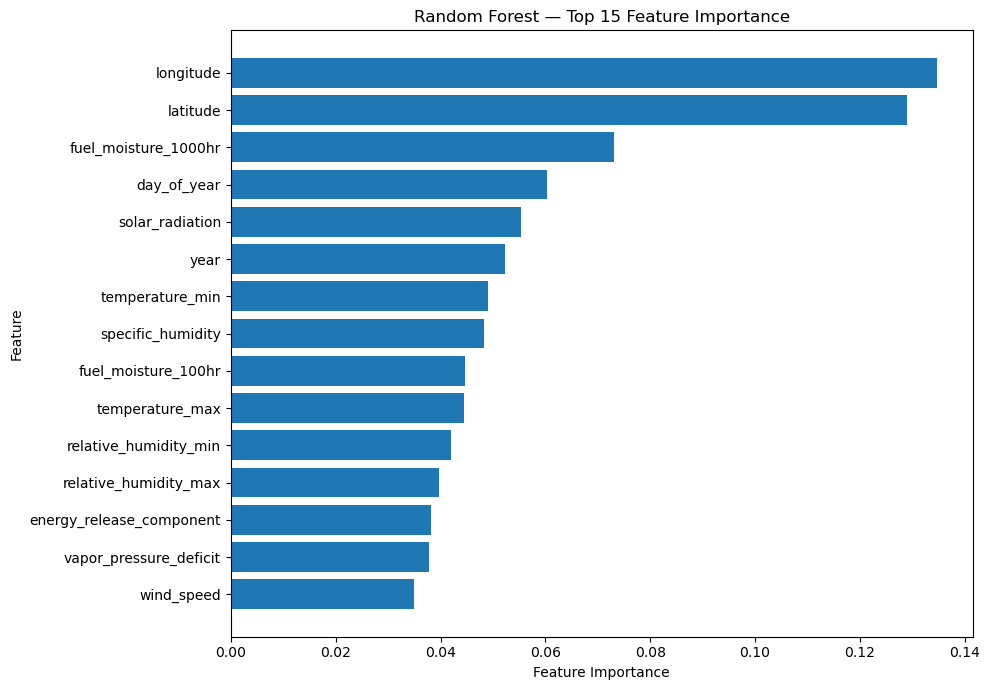

In [31]:
import matplotlib.pyplot as plt

top_15 = feature_importance.head(15).sort_values(
    by="importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_15["feature"],
    top_15["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest — Top 15 Feature Importance")

plt.tight_layout()
plt.show()

# Step 7.10.2 — Create Selected-Feature Datasets

In [25]:
# ============================================================
# STEP 7.10.2 — CREATE SELECTED-FEATURE DATASETS
# ============================================================

# Keep only the selected features for the tuning dataset
# and validation dataset.

X_tune_selected = X_tune[top_features]

X_validation_selected = X_validation[top_features]

print("Selected tuning shape:", X_tune_selected.shape)
print("Selected validation shape:", X_validation_selected.shape)

Selected tuning shape: (200000, 15)
Selected validation shape: (1326842, 15)


# Step 7.10.3 — Train Random Forest Using Selected Features

In [26]:
# ============================================================
# STEP 7.10.3 — TRAIN SELECTED-FEATURE RANDOM FOREST
# ============================================================

# Use the best hyperparameters found during RandomizedSearchCV.
# Train only on the 200,000-row tuning dataset.
# The validation and test sets are NOT used for training.

rf_selected = RandomForestClassifier(
    n_estimators=250,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=5,
    max_features="log2",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest with selected features...")

rf_selected.fit(
    X_tune_selected,
    y_tune
)

print("Selected-feature Random Forest training completed.")

Training Random Forest with selected features...
Selected-feature Random Forest training completed.


# Step 7.10.4 — Predict on Validation Data

In [27]:
# ============================================================
# STEP 7.10.4 — PREDICT ON VALIDATION DATA
# ============================================================

# Predict using the selected-feature Random Forest.
# The test set remains completely untouched.

y_validation_pred_selected = rf_selected.predict(
    X_validation_selected
)

print("Selected-feature validation predictions completed.")

Selected-feature validation predictions completed.


In [28]:
# Calculate predicted probabilities for the wildfire class.

y_validation_proba_selected = rf_selected.predict_proba(
    X_validation_selected
)[:, 1]

print("Selected-feature validation probabilities calculated.")

Selected-feature validation probabilities calculated.


# Step 7.10.5 — Calculate the metrics:

In [29]:
# ============================================================
# STEP 7.10.5 — EVALUATE SELECTED-FEATURE RANDOM FOREST
# ============================================================

accuracy_selected = accuracy_score(
    y_validation,
    y_validation_pred_selected
)

precision_selected = precision_score(
    y_validation,
    y_validation_pred_selected,
    zero_division=0
)

recall_selected = recall_score(
    y_validation,
    y_validation_pred_selected,
    zero_division=0
)

f1_selected = f1_score(
    y_validation,
    y_validation_pred_selected,
    zero_division=0
)

roc_auc_selected = roc_auc_score(
    y_validation,
    y_validation_proba_selected
)

print("Random Forest - Selected Features")
print("----------------------------------")
print(f"Accuracy : {accuracy_selected:.6f}")
print(f"Precision: {precision_selected:.6f}")
print(f"Recall   : {recall_selected:.6f}")
print(f"F1-score : {f1_selected:.6f}")
print(f"ROC-AUC  : {roc_auc_selected:.6f}")

Random Forest - Selected Features
----------------------------------
Accuracy : 0.528843
Precision: 0.106553
Recall   : 0.646746
F1-score : 0.182962
ROC-AUC  : 0.621741


# Step 7.11 — Random Forest Experiment Comparison

In [30]:
# ============================================================
# STEP 7.11 — RANDOM FOREST EXPERIMENT COMPARISON
# ============================================================

rf_experiment_comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Optimized Random Forest",
        "Random Forest - Selected Features"
    ],
    "Accuracy": [
        accuracy,
        accuracy_tuned,
        accuracy_selected
    ],
    "Precision": [
        precision,
        precision_tuned,
        precision_selected
    ],
    "Recall": [
        recall,
        recall_tuned,
        recall_selected
    ],
    "F1-score": [
        f1,
        f1_tuned,
        f1_selected
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_tuned,
        roc_auc_selected
    ]
})

print("Random Forest Experiment Comparison")
print("------------------------------------")
print(
    rf_experiment_comparison.to_string(index=False)
)

Random Forest Experiment Comparison
------------------------------------
                            Model  Accuracy  Precision   Recall  F1-score  ROC-AUC
           Baseline Random Forest  0.918410   0.254237 0.000139  0.000277 0.600557
          Optimized Random Forest  0.543298   0.107568 0.630308  0.183773 0.622228
Random Forest - Selected Features  0.528843   0.106553 0.646746  0.182962 0.621741
